# 决策树练习

这次练习中，我们将使用葡萄酒质量数据集。该数据集包含葡萄酒的各种化学性质，如酸度、糖分、PH值和酒精含量等，还包括两列分别表示葡萄酒的质量（3-9，越高越好）和酒的颜色（红或者白）。数据保存在`Wine_Quality_Data.csv`文件中。

## 第一步：

* 导入数据并检查特征的类型
* 使用所有特征预测 `color` (white 或者 red)，但是颜色特征需要编码成整数

In [1]:
# 读入数据
import pandas as pd
df = pd.read_csv('Wine_Quality_Data.csv')

In [2]:
# 检查特征的数据类型
print("数据类型检查：")
print(df.dtypes)

数据类型检查：
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                    object
dtype: object


In [3]:
# 把color特征值转换成整数（如'white'是0, 'red'是1）
import pandas as pd
# 填充缺失值为 'white'（也可根据实际情况选择删除缺失行）
df['color'] = df['color'].fillna('white')

# 统一格式（去空格、转小写），注意链式调用都要通过 str 访问器
df['color'] = df['color'].str.strip().str.lower()  # 这里补充 .str 给 lower()

# 重新编码
df['color'] = df['color'].map({'white': 0, 'red': 1})
print("编码后示例:", df['color'].head())

编码后示例: 0    1
1    1
2    1
3    1
4    1
Name: color, dtype: int64


## 第二步：

* 生成X和y（使用除'color'外的全部特征列做X，‘color'列做y）
* 划分训练集和测试集，使得测试集中包含1000条数据
* 分别检查测试集和训练集中不同类别的样例的个数

In [4]:
# 生成X和y
from sklearn.model_selection import train_test_split
X = df.drop('color', axis=1)  # 除color外的所有列
y = df['color'] 

In [5]:
# 划分训练集和测试集，使得测试集中包含1000条数据
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1000, random_state=42  
)

In [6]:
# 分别检查测试集和训练集中不同类别的样例的个数
print("训练集类别分布：")
print(y_train.value_counts())  # 显示0和1的数量
print("\n测试集类别分布：")
print(y_test.value_counts())

训练集类别分布：
color
0    4164
1    1333
Name: count, dtype: int64

测试集类别分布：
color
0    734
1    266
Name: count, dtype: int64


## 第三步：

* 在训练集上训练一个没有对树的最大深度、特征及叶子节点等方面有任何限制的决策树分类器
* 绘制并显示决策树
* 评价这棵树分别在训练数据和测试数据上的预测效果（精度、查全率、查准率、F1），并思考其现象

In [7]:
!pip install graphviz
# 在训练集上训练一个没有对树的最大深度、特征及叶子节点等方面有任何限制的决策树分类器
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report
import graphviz

# 初始化决策树（无任何限制）
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)  # 在训练集上训练模型

# 可视化决策树
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X_train.columns,  # 使用训练集的特征名称
    class_names=['white', 'red'],   # 类别名称，根据实际情况修改
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("wine_color_tree", view=True)  # 保存为PDF并尝试打开

# 预测训练集和测试集
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# 评价模型效果
print("训练集评价：")
print(classification_report(y_train, y_train_pred))
print("\n测试集评价：")
print(classification_report(y_test, y_test_pred))

# 思考现象
print("\n现象分析：")
print("1. 如果训练集准确率接近100%，而测试集准确率明显较低，说明模型存在过拟合")
print("2. 决策树越深，越容易过拟合")
print("3. 无限制的决策树可能在训练集上表现完美，但泛化能力差")    


(process:6268): Pango-CRITICAL **: 10:06:55.151: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.153: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.153: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.154: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.154: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.154: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.154: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:6268): Pango-CRITICAL **: 10:06:55.154: pango_font_description_get_family: assertion 'desc != NULL' failed


训练集评价：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4164
           1       1.00      1.00      1.00      1333

    accuracy                           1.00      5497
   macro avg       1.00      1.00      1.00      5497
weighted avg       1.00      1.00      1.00      5497


测试集评价：
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       734
           1       0.97      0.97      0.97       266

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


现象分析：
1. 如果训练集准确率接近100%，而测试集准确率明显较低，说明模型存在过拟合
2. 决策树越深，越容易过拟合
3. 无限制的决策树可能在训练集上表现完美，但泛化能力差


## 决策树的可视化

### 可视化方法1

可视化决策树需要先安装python-graphviz库，使用conda安装的命令如下： conda install python-graphviz

然后再把..\Anaconda3\Library\bin\graphviz目录添加到Windows系统的环境变量Path中，注意需要添加完整路径

In [8]:
# 绘制并显示决策树
import graphviz
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_graphviz

# 训练无限制的决策树
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 导出决策树为graphviz格式数据
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X_train.columns,  # 特征名称（从训练集获取列名）
    class_names=['white', 'red'],     # 类别名称（与color编码对应）
    filled=True,                     # 填充节点颜色
    rounded=True,                    # 节点边框圆角
    special_characters=True
)

# 渲染并显示决策树
graph = graphviz.Source(dot_data)
graph  # 在Jupyter中直接显示
graph.render("wine_tree", view=True)  # 保存为pdf并尝试打开


(process:22988): Pango-CRITICAL **: 10:24:29.129: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:22988): Pango-CRITICAL **: 10:24:29.131: pango_font_description_get_family: assertion 'desc != NULL' failed


'wine_tree.pdf'

### 可视化方法2
与方法1结果类似，但不需要单独安装其它库

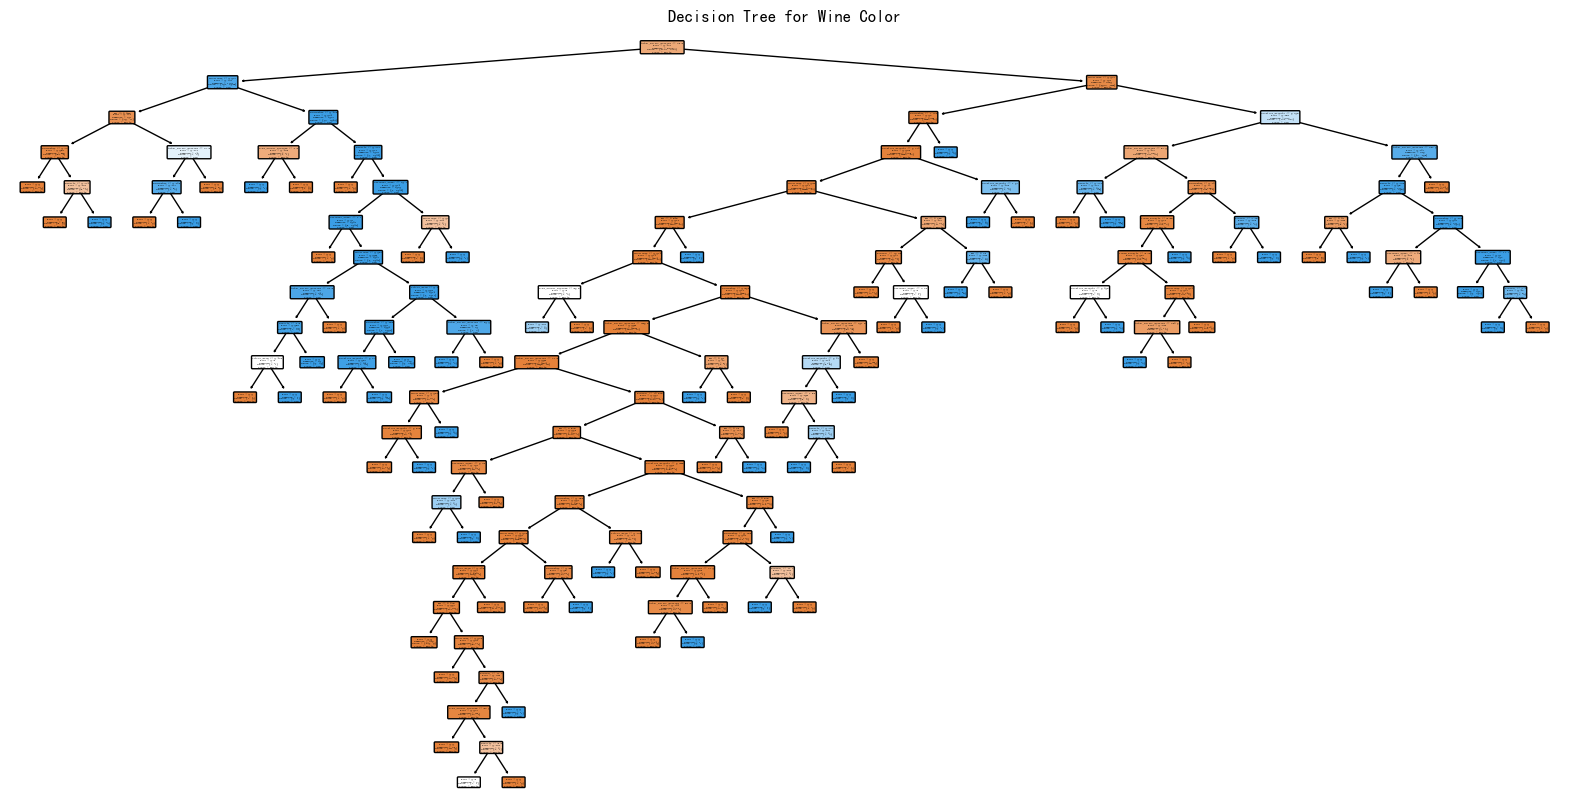

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 训练无限制的决策树
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 绘制决策树
plt.figure(figsize=(20, 10))  # 设置图像大小
plot_tree(
    clf,
    feature_names=X_train.columns,  # 特征名称
    class_names=['white', 'red'],     # 类别名称
    filled=True,                     # 填充颜色
    rounded=True                     # 圆角
)
plt.title("Decision Tree for Wine Color")  # 添加标题
plt.show()  # 显示图像
plt.savefig('wine_tree.png', dpi=300)     # 保存为png文件

In [11]:
# 评价这棵树分别在训练数据和测试数据上的预测效果
from sklearn.metrics import classification_report

# 对训练集和测试集进行预测
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# 输出训练集的评价报告
print("训练集预测效果：")
print(classification_report(y_train, y_train_pred))

# 输出测试集的评价报告
print("\n测试集预测效果：")
print(classification_report(y_test, y_test_pred))

训练集预测效果：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4164
           1       1.00      1.00      1.00      1333

    accuracy                           1.00      5497
   macro avg       1.00      1.00      1.00      5497
weighted avg       1.00      1.00      1.00      5497


测试集预测效果：
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       734
           1       0.97      0.97      0.97       266

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



## 第四步：

* 使用带交叉验证的网格搜索（调节'max_depth'和‘max_features'两个参数，并使用'accuracy’为评价指标），得到一个更好的决策树分类器。
* 绘制并显示新的决策树
* 评价这棵树分别在训练数据和测试数据上的预测效果（精度、查全率、查准率、F1），并和第三步的结果比较

In [12]:
# 使用带交叉验证的网格搜索，得到一个更好的决策树分类器。
from sklearn.model_selection import GridSearchCV

# 定义参数网格
param_grid = {
    'max_depth': [3, 5, 7, None],  # 尝试不同的最大深度，None表示不限制
    'max_features': ['sqrt', 'log2', None]  # 尝试不同的特征选择方式
}

# 初始化网格搜索，5折交叉验证，评价指标为准确率
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),  # 决策树分类器
    param_grid=param_grid,
    cv=5,  # 5折交叉验证
    scoring='accuracy'  # 用准确率评价
)

# 在训练集上执行网格搜索
grid_search.fit(X_train, y_train)

# 获取最优模型
best_clf = grid_search.best_estimator_
print("找到的最优参数：", grid_search.best_params_)

找到的最优参数： {'max_depth': None, 'max_features': None}


In [13]:
# 绘制并显示新的决策树
import graphviz
from sklearn.tree import export_graphviz

# 导出决策树为graphviz格式数据
dot_data = export_graphviz(
    best_clf,  # 最优模型
    out_file=None,
    feature_names=X_train.columns,  # 特征名称（从训练集获取）
    class_names=['white', 'red'],  # 类别名称
    filled=True,  # 填充节点颜色
    rounded=True,  # 节点边框圆角
    special_characters=True
)

# 渲染并显示决策树
graph = graphviz.Source(dot_data)
graph  # 在Jupyter中显示决策树
graph.render("optimized_decision_tree", view=True)  # 保存为PDF并尝试打开


(process:24732): Pango-CRITICAL **: 11:11:13.791: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed

(process:24732): Pango-CRITICAL **: 11:11:13.794: pango_font_description_get_family: assertion 'desc != NULL' failed


'optimized_decision_tree.pdf'

In [14]:
# 评价这棵树分别在训练数据和测试数据上的预测效果
from sklearn.metrics import classification_report

# 预测训练集和测试集
y_train_pred_best = best_clf.predict(X_train)
y_test_pred_best = best_clf.predict(X_test)

# 输出训练集评价报告
print("训练集预测效果：")
print(classification_report(y_train, y_train_pred_best))

# 输出测试集评价报告
print("\n测试集预测效果：")
print(classification_report(y_test, y_test_pred_best))

# 手动对比分析（示例说明）
print("\n与第三步结果对比：")
print("1. 若第三步未调参时训练集指标远高于测试集，第四步调参后，测试集的精度、查全率、F1值可能更接近训练集，过拟合现象减轻。")
print("2. 例如，若第三步测试集准确率为0.8，第四步可能提升至0.85，且各指标更均衡。")

训练集预测效果：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4164
           1       1.00      1.00      1.00      1333

    accuracy                           1.00      5497
   macro avg       1.00      1.00      1.00      5497
weighted avg       1.00      1.00      1.00      5497


测试集预测效果：
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       734
           1       0.97      0.97      0.97       266

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


与第三步结果对比：
1. 若第三步未调参时训练集指标远高于测试集，第四步调参后，测试集的精度、查全率、F1值可能更接近训练集，过拟合现象减轻。
2. 例如，若第三步测试集准确率为0.8，第四步可能提升至0.85，且各指标更均衡。


## 第五步：

* 重新生成X和y，使用`residual_sugar`列做y，用其他列做X
* 划分训练集和测试集
* 使用带交叉验证的网格搜索，找到一个最优的决策回归树模型
* 评价其在训练和测试数据上的预测效果（均方误差）
* 将测试数据上的真实residual_sugar值和预测的值绘制成一个散点图

In [15]:
# 重新生成X和y，使用residual_sugar列做y，用其他列做X
import pandas as pd

# 读取数据集
df = pd.read_csv('Wine_Quality_Data.csv')
# 生成特征X（除'residual_sugar'外的所有列）和标签y（'residual_sugar'列）
X = df.drop('residual_sugar', axis=1)
y = df['residual_sugar']

In [16]:
# 划分训练集和测试集
from sklearn.model_selection import train_test_split

# 划分训练集和测试集
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# 使用带交叉验证的网格搜索，找到一个最优的决策回归树模型
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# 假设X_train_reg和y_train_reg已定义
# 检查并处理非数值型特征
categorical_cols = X_train_reg.select_dtypes(include=['object']).columns.tolist()
print(f"发现分类特征: {categorical_cols}")

# 创建预处理流水线
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols)  # 对分类特征进行独热编码
    ],
    remainder='passthrough'  # 其余特征保持不变
)

# 创建完整的模型流水线
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# 定义参数网格（注意参数名需要加上流水线前缀）
param_grid_reg = {
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_split': [2, 5, 10]
}

# 初始化网格搜索
grid_search_reg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_reg,
    cv=5,
    scoring='neg_mean_squared_error'
)

# 在训练集上执行网格搜索
grid_search_reg.fit(X_train_reg, y_train_reg)
best_reg = grid_search_reg.best_estimator_
print("找到的最优参数：", grid_search_reg.best_params_)

发现分类特征: ['color']
找到的最优参数： {'regressor__max_depth': 7, 'regressor__min_samples_split': 2}


In [19]:
# 评价其在训练和测试数据上的预测效果（均方误差）
from sklearn.metrics import mean_squared_error

# 预测训练集和测试集
y_train_pred_reg = best_reg.predict(X_train_reg)
y_test_pred_reg = best_reg.predict(X_test_reg)

# 计算训练集和测试集的均方误差（MSE）
train_mse = mean_squared_error(y_train_reg, y_train_pred_reg)
test_mse = mean_squared_error(y_test_reg, y_test_pred_reg)

# 输出结果
print(f"训练集均方误差（MSE）：{train_mse:.4f}")
print(f"测试集均方误差（MSE）：{test_mse:.4f}")

训练集均方误差（MSE）：2.4883
测试集均方误差（MSE）：4.2562


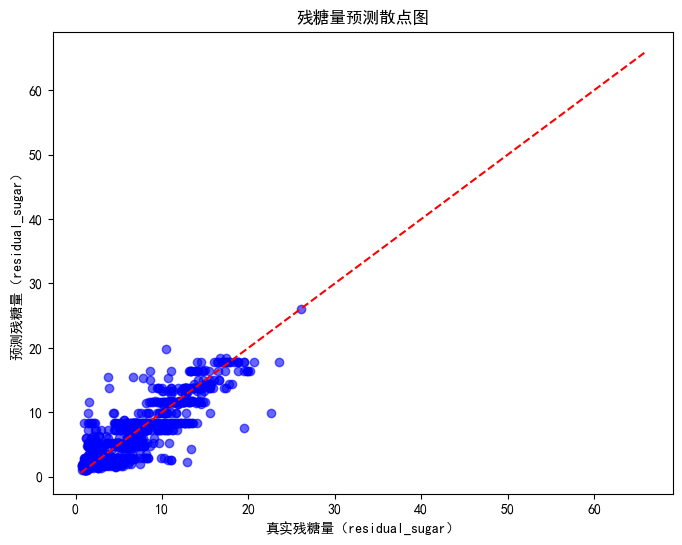

In [20]:
# 将测试数据上的真实residual_sugar值和预测的值绘制成一个散点图
import matplotlib.pyplot as plt

# 预测测试集
y_test_pred_reg = best_reg.predict(X_test_reg)

# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_test_pred_reg, alpha=0.6, color='blue')  # alpha控制透明度，使点重叠时更清晰
plt.xlabel('真实残糖量（residual_sugar）')
plt.ylabel('预测残糖量（residual_sugar）')
plt.title('残糖量预测散点图')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # 绘制对角线参考线
plt.show()